In [3]:
import numpy as np

X_train = np.load("processed_data/X_train.npy")
y_train = np.load("processed_data/y_train.npy")

print(X_train.shape)
print(y_train.shape)

(17731, 30, 16)
(17731,)


In [4]:
import torch.nn as nn

class LSTMRULModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMRULModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        output = self.fc(last_output)
        return output.squeeze()

In [5]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = X_train.shape[2]

model = LSTMRULModel(input_size=input_size).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

X_train_lstm, X_val_lstm, y_train_lstm, y_val_lstm = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = RULDataset(X_train_lstm, y_train_lstm)
val_dataset = RULDataset(X_val_lstm, y_val_lstm)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [16]:
EPOCHS = 50

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}], "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch [1/50], Train Loss: 236.8485, Val Loss: 158.7649
Epoch [2/50], Train Loss: 237.1987, Val Loss: 155.9083
Epoch [3/50], Train Loss: 243.2985, Val Loss: 156.2888
Epoch [4/50], Train Loss: 236.4003, Val Loss: 154.5786
Epoch [5/50], Train Loss: 238.8301, Val Loss: 167.6743
Epoch [6/50], Train Loss: 232.8667, Val Loss: 163.4503
Epoch [7/50], Train Loss: 234.0526, Val Loss: 158.0755
Epoch [8/50], Train Loss: 230.7117, Val Loss: 160.0113
Epoch [9/50], Train Loss: 232.4827, Val Loss: 160.0246
Epoch [10/50], Train Loss: 232.0561, Val Loss: 149.8417
Epoch [11/50], Train Loss: 231.7297, Val Loss: 151.2820
Epoch [12/50], Train Loss: 232.2481, Val Loss: 150.4270
Epoch [13/50], Train Loss: 230.9208, Val Loss: 158.6523
Epoch [14/50], Train Loss: 227.5195, Val Loss: 155.1094
Epoch [15/50], Train Loss: 228.8926, Val Loss: 147.8565
Epoch [16/50], Train Loss: 224.1906, Val Loss: 152.1867
Epoch [17/50], Train Loss: 227.9073, Val Loss: 168.2894
Epoch [18/50], Train Loss: 227.4229, Val Loss: 174.6662
E

In [11]:
torch.save(model.state_dict(), "models/lstm_rul_model.pth")

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        all_preds.extend(outputs.cpu().numpy())
        all_targets.extend(y_batch.numpy())

mae = mean_absolute_error(all_targets, all_preds)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
r2 = r2_score(all_targets, all_preds)

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)
print("LSTM R2:", r2)

LSTM MAE: 8.965923728659215
LSTM RMSE: 12.548697678853099
LSTM R2: 0.9091332771438627


In [13]:
import os

os.makedirs("results/lstm", exist_ok=True)
os.makedirs("results", exist_ok=True)

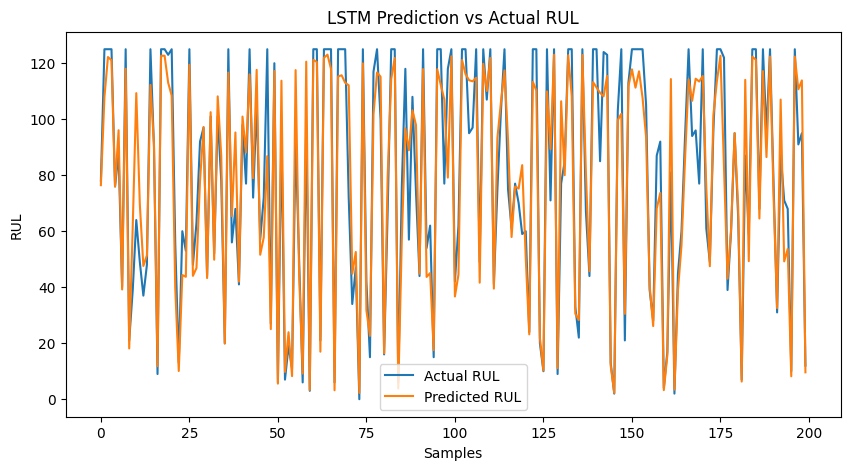

In [18]:
plt.figure(figsize=(10,5))
plt.plot(all_targets[:200], label="Actual RUL")
plt.plot(all_preds[:200], label="Predicted RUL")
plt.xlabel("Samples")
plt.ylabel("RUL")
plt.title("LSTM Prediction vs Actual RUL")
plt.legend()
plt.savefig("results/lstm/lstm_prediction_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
loss curve

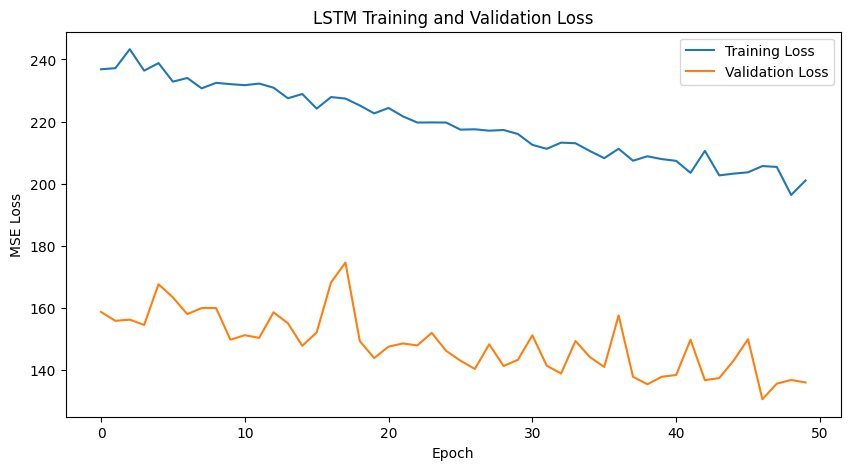

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")

plt.legend()

plt.savefig(
    "results/lstm/lstm_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

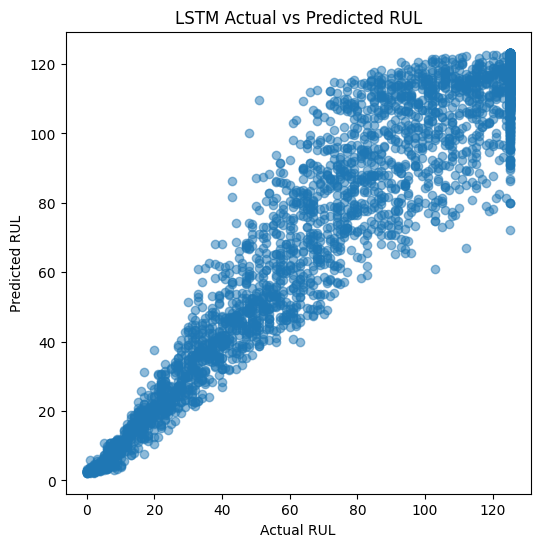

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(all_targets, all_preds, alpha=0.5)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("LSTM Actual vs Predicted RUL")
plt.savefig("results/lstm/lstm_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

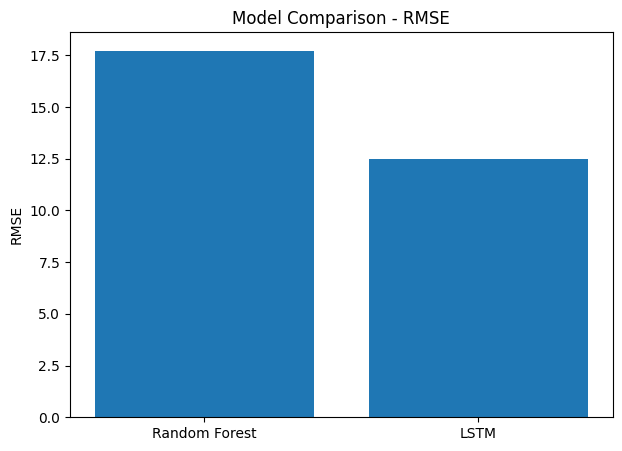

In [21]:
models = ["Random Forest", "LSTM"]
rmse_values = [17.73199961103676, 12.47925997478342]

plt.figure(figsize=(7,5))
plt.bar(models, rmse_values)
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")
plt.savefig("results/lstm/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
columns = ["engine_id", "cycle"] 
columns += [f"setting_{i}" for i in range(1, 4)]
columns += [f"sensor_{i}" for i in range(1, 22)]

In [30]:
import pandas as pd
test_df = pd.read_csv(
    "data/test_FD001.txt",
    sep=r"\s+",
    header=None
)

test_df.columns = columns

In [31]:
true_rul = pd.read_csv(
    "data/RUL_FD001.txt",
    sep=r"\s+",
    header=None
)

true_rul.columns = ["RUL"]

In [36]:
drop_cols = [
    "setting_3",
    "sensor_1",
    "sensor_5",
    "sensor_6",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

test_df = test_df.drop(columns=drop_cols, errors="ignore")

In [37]:
feature_cols = [
    col for col in test_df.columns
    if col not in ["engine_id", "cycle"]
]

print(len(feature_cols))
print(feature_cols)

16
['setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [38]:
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [39]:
print(test_df.columns.tolist())

['engine_id', 'cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [40]:
def create_test_sequences(test_df, feature_cols, window_size=30):
    X_test = []

    for engine_id in test_df["engine_id"].unique():
        engine_data = test_df[test_df["engine_id"] == engine_id].reset_index(drop=True)
        features = engine_data[feature_cols].values

        if len(features) >= window_size:
            X_test.append(features[-window_size:])
        else:
            pad_size = window_size - len(features)
            padding = np.zeros((pad_size, features.shape[1]))
            padded_sequence = np.vstack((padding, features))
            X_test.append(padded_sequence)

    return np.array(X_test)

In [41]:
WINDOW_SIZE=30
RUL_CAP = 125

In [42]:
X_test = create_test_sequences(test_df, feature_cols, WINDOW_SIZE)
y_test = true_rul["RUL"].clip(upper=RUL_CAP).values

In [43]:
import torch
from torch.utils.data import Dataset

class RULDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [44]:
from torch.utils.data import DataLoader

test_dataset = RULDataset(X_test, y_test)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [52]:
engine_index = 7

single_engine = X_test[engine_index]
single_engine = np.expand_dims(single_engine, axis=0)

print(single_engine.shape)

(1, 30, 16)


In [53]:
model.eval()

with torch.no_grad():
    single_engine_tensor = torch.tensor(single_engine, dtype=torch.float32).to(device)
    prediction = model(single_engine_tensor)

predicted_rul = prediction.item()
actual_rul = y_test[engine_index]

print("Predicted RUL:", predicted_rul)
print("Actual RUL:", actual_rul)
print("Error:", abs(predicted_rul - actual_rul))

Predicted RUL: 93.4671859741211
Actual RUL: 95
Error: 1.5328140258789062


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model.eval()

test_preds = []
test_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        test_preds.extend(outputs.cpu().numpy())
        test_targets.extend(y_batch.numpy())

test_mae = mean_absolute_error(test_targets, test_preds)
test_rmse = np.sqrt(mean_squared_error(test_targets, test_preds))
test_r2 = r2_score(test_targets, test_preds)

print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)

Test MAE: 9.838773622512818
Test RMSE: 13.647740833456625
Test R2: 0.8840123298732931


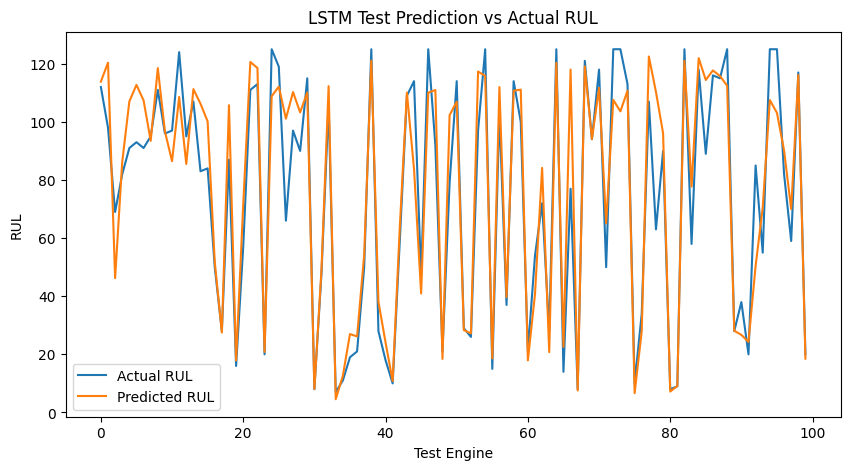

In [55]:
import os
import matplotlib.pyplot as plt

os.makedirs("results/lstm", exist_ok=True)

plt.figure(figsize=(10,5))
plt.plot(test_targets, label="Actual RUL")
plt.plot(test_preds, label="Predicted RUL")
plt.xlabel("Test Engine")
plt.ylabel("RUL")
plt.title("LSTM Test Prediction vs Actual RUL")
plt.legend()
plt.savefig("results/lstm/lstm_test_prediction_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

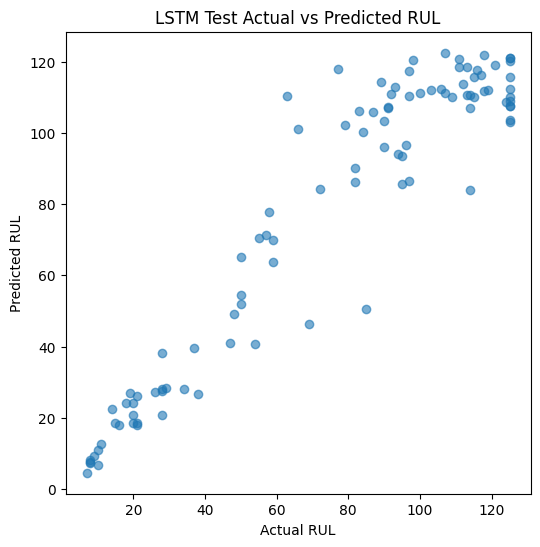

In [56]:
plt.figure(figsize=(6,6))
plt.scatter(test_targets, test_preds, alpha=0.6)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("LSTM Test Actual vs Predicted RUL")
plt.savefig("results/lstm/lstm_test_scatter.png", dpi=300, bbox_inches="tight")
plt.show()